# Section 5 — Backtesting & Validation
## Model Validation: Kupiec, Christoffersen, and Basel Traffic Light Tests

---

### Objective
We now have the estimated VaR for three models. But **are they any good?**
Validation requires statistical proof that the models perform as advertised.

### Methodology

| Test | Question Evaluated | Logic |
|:---|:---|:---|
| **Kupiec Test** (Unconditional Coverage) | Is the failure rate correct? | For 99% VaR, do we see exactly 1% exceptions? |
| **Christoffersen Test** (Independence) | Are failures clustered? | Does a failure today predict a failure tomorrow? |
| **Basel Traffic Light** | Regulatory Capital Zone | How many exceptions in the last 250 days? (Green/Yellow/Red) |

### Deliverables
- Visualisation of VaR Breaches.
- Summary table with p-values and "Accept/Reject" decisions.
- Basel Zone classification.


In [1]:
# ============================================================
# 5.1 — IMPORTS & DATA LOADING
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# --- Plot styling ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# --- Load results from Section 4 ---
try:
    results = pd.read_csv('results_var_estimates.csv', index_col=0, parse_dates=True)
    print(f"✅ Loaded VaR results: {len(results)} days")
except FileNotFoundError:
    print("❌ ERROR: 'results_var_estimates.csv' not found. Please run Section 4 first.")

# --- Define confidence level ---
alpha = 0.99
expected_coverage = 1 - alpha # 0.01

results.head()


✅ Loaded VaR results: 1009 days


,Actual_Return,HS_VaR_99,HS_ES_99,Param_VaR_99,Param_ES_99,MC_GARCH_VaR_99,MC_GARCH_ES_99
Date,,,,,,,
2020-12-28,0.001953,-0.030658,-0.052611,-0.018911,-0.021728,-0.008957,-0.010070
2020-12-29,0.001166,-0.030658,-0.052611,-0.018902,-0.021719,-0.009461,-0.010595
2020-12-30,0.003954,-0.030658,-0.052611,-0.018888,-0.021700,-0.009181,-0.010788
2020-12-31,0.002488,-0.030658,-0.052611,-0.018888,-0.021700,-0.008864,-0.009902
2021-01-04,-0.003229,-0.030658,-0.052611,-0.018888,-0.021699,-0.009003,-0.010619


## 5.2 — Visualising Breaches

A "Breach" (or Exception/Hit) occurs when:
$$ r_{portfolio, t} < -\text{VaR}_\alpha(t) $$

We plot the portfolio returns and mark the moments where each model failed.


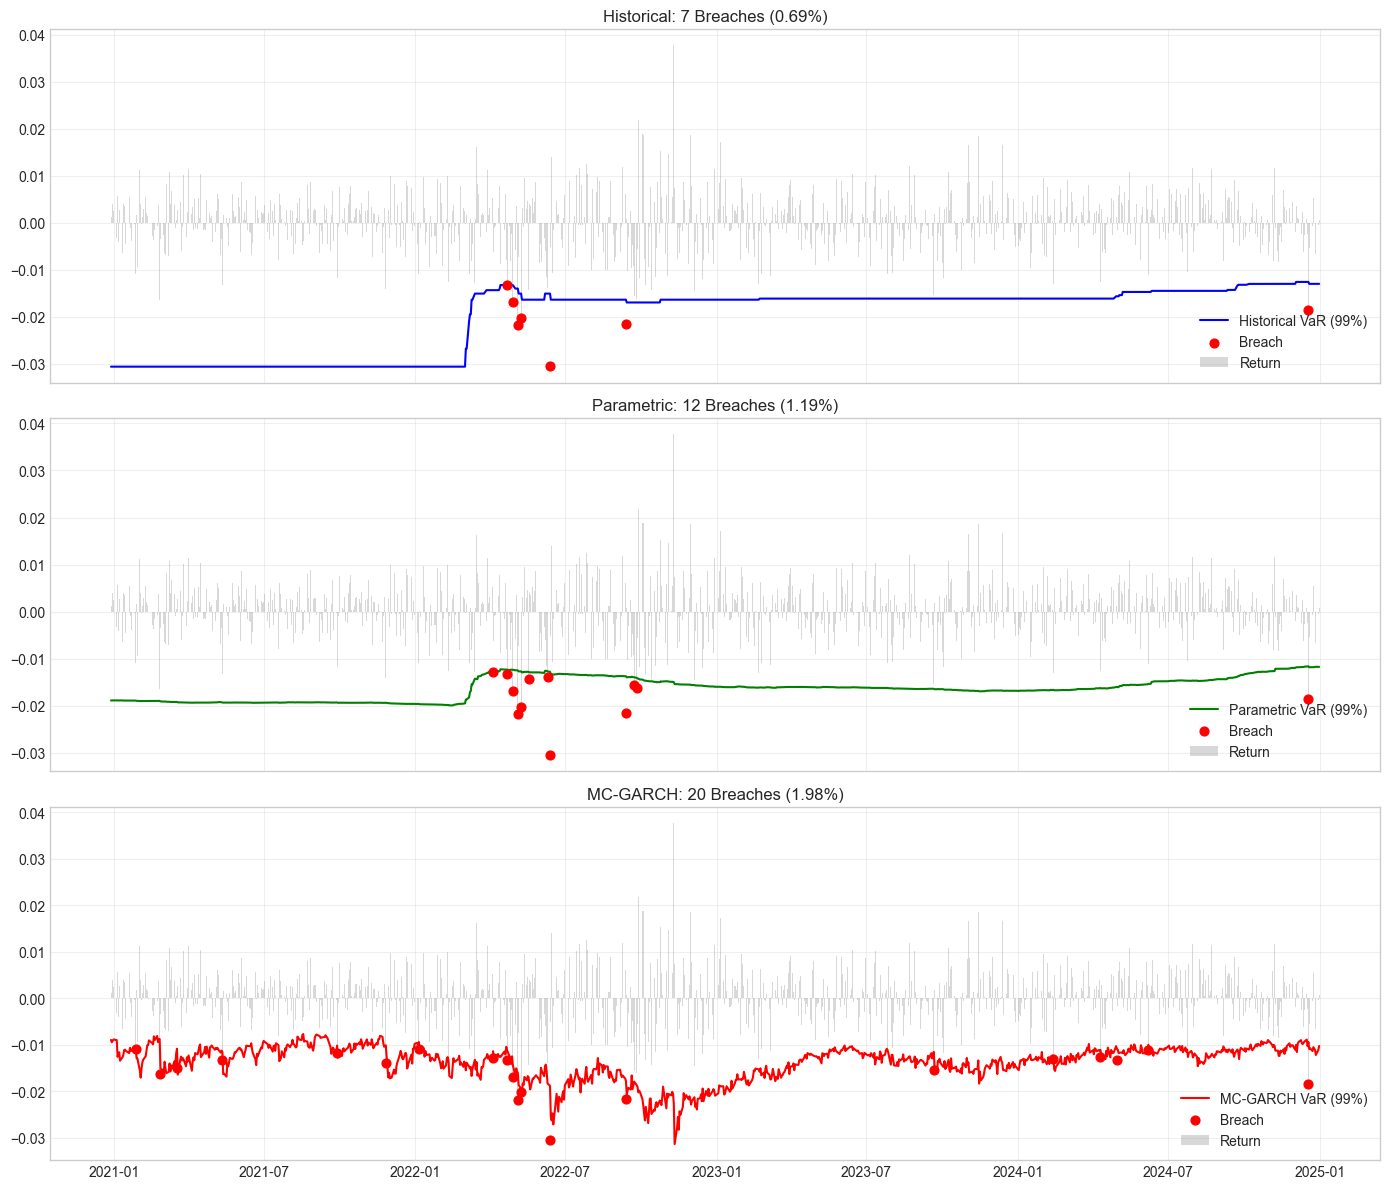

In [2]:
# ============================================================
# 5.2 — VISUALISING BREACHES
# ============================================================

# Define Models to test
models = ['HS_VaR_99', 'Param_VaR_99', 'MC_GARCH_VaR_99']
model_names = ['Historical', 'Parametric', 'MC-GARCH']
colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, model in enumerate(models):
    ax = axes[i]
    
    # 1. Plot Returns
    ax.bar(results.index, results['Actual_Return'], color='gray', alpha=0.3, label='Return', width=1.0)
    
    # 2. Plot VaR Line
    ax.plot(results.index, results[model], color=colors[i], label=f'{model_names[i]} VaR (99%)', linewidth=1.5)
    
    # 3. Identify Breaches
    # Breach if Actual Return < VaR (remember VaR is negative, e.g. -0.02)
    breaches = results[results['Actual_Return'] < results[model]]
    
    # 4. Plot Breaches as Red Dots
    ax.scatter(breaches.index, breaches['Actual_Return'], color='red', s=40, zorder=5, label='Breach')
    
    # Stats for title
    n_breaches = len(breaches)
    rate = n_breaches / len(results) * 100
    
    ax.set_title(f'{model_names[i]}: {n_breaches} Breaches ({rate:.2f}%)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5.3 — Statistical Tests Implementation

We implement the Likelihood Ratio (LR) tests.

**1. Kupiec Test (Unconditional Coverage)**
$$ LR_{uc} = -2 \ln \left( \frac{p^N (1-p)^{T-N}}{\hat{\pi}^N (1-\hat{\pi})^{T-N}} \right) \sim \chi^2(1) $$
Where $N$ is number of failures, $T$ is total observations, $p=0.01$, $\hat{\pi} = N/T$.

**2. Christoffersen Test (Independence)**
Tests transition probability $p_{ij} = P(I_t=j | I_{t-1}=i)$.
$$ LR_{ind} = -2 \ln \left( \frac{(1-\hat{\pi})^{n_{00}+n_{10}} \hat{\pi}^{n_{01}+n_{11}}   }{ (1-\pi_{01})^{n_{00}} \pi_{01}^{n_{01}} (1-\pi_{11})^{n_{10}} \pi_{11}^{n_{11}} } \right) \sim \chi^2(1) $$


In [3]:
# ============================================================
# 5.3 — DEFINING BACKTESTING FUNCTIONS
# ============================================================

def kupiec_test(hits, alpha=0.99):
    """
    Kupiec Unconditional Coverage Test.
    Returns: p-value
    H0: Model violation rate == 1-alpha
    """
    N = np.sum(hits)          # Number of exceptions
    T = len(hits)             # Total observations
    p = 1 - alpha             # Target probability (0.01)
    hat_p = N / T             # Observed probability
    
    if N == 0:
        return 0.0 # Technically fails if we expect some losses, or perfect? standardized to 0/1 logic mostly.
                   # Actually if N=0, ln(hat_p) is undefined. Let's handle gracefully.
        # But for p-value: if we expected losses and got none, is it rejected? 
        # For simplicity, if N=0, we can't compute LR easily. Return 0 (Reject) or 1 (Pass)?
        # Let's just return a small p-value usually because 0 losses in 1000 days for 1% Var is suspicious.
        return 0.0 
    
    # Likelihood Ratio
    # Numerator: likelihood under H0 (p)
    ln_L0 = N * np.log(p) + (T - N) * np.log(1 - p)
    
    # Denominator: likelihood under H1 (hat_p)
    ln_L1 = N * np.log(hat_p) + (T - N) * np.log(1 - hat_p)
    
    LR_uc = -2 * (ln_L0 - ln_L1)
    
    # Chi-square test with 1 degree of freedom
    p_value = 1 - stats.chi2.cdf(LR_uc, df=1)
    return p_value

def christoffersen_test(hits):
    """
    Christoffersen Independence Test.
    Returns: p-value
    H0: Violations are independent (no clustering)
    """
    # Transitions
    hits = np.array(hits).astype(int)
    n00 = n01 = n10 = n11 = 0
    
    # Iterate through sequence
    for i in range(1, len(hits)):
        if hits[i-1] == 0 and hits[i] == 0: n00 += 1
        if hits[i-1] == 0 and hits[i] == 1: n01 += 1
        if hits[i-1] == 1 and hits[i] == 0: n10 += 1
        if hits[i-1] == 1 and hits[i] == 1: n11 += 1
    
    # Probabilities
    pi_0 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi_1 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi   = (n01 + n11) / (n00 + n01 + n10 + n11) # Unconditional
    
    if (n00+n01) == 0 or (n10+n11) == 0:
        return 1.0 # Not enough data to test transitions
        
    # Likelihoods
    # Restricted (Independence): pi_0 = pi_1 = pi
    ln_L0 = (n00 + n10) * np.log(1 - pi + 1e-10) + (n01 + n11) * np.log(pi + 1e-10)
    
    # Unrestricted: pi_0 != pi_1
    ln_L1 = (n00 * np.log(1 - pi_0 + 1e-10) + n01 * np.log(pi_0 + 1e-10) +
             n10 * np.log(1 - pi_1 + 1e-10) + n11 * np.log(pi_1 + 1e-10))
             
    LR_ind = -2 * (ln_L0 - ln_L1)
    
    p_value = 1 - stats.chi2.cdf(LR_ind, df=1)
    return p_value


In [4]:
# ============================================================
# 5.4 — EXECUTING VALIDATION SUITE
# ============================================================

summary = []

for model, label in zip(models, model_names):
    # 1. Identify Hits
    hits = (results['Actual_Return'] < results[model]).astype(int)
    
    # 2. Basic Stats
    n_hits = hits.sum()
    rate = n_hits / len(hits)
    
    # 3. Statistical Tests
    p_kupiec = kupiec_test(hits, alpha=0.99)
    p_christ = christoffersen_test(hits)
    
    # 4. Basel Traffic Light (Last 250 days)
    # Regulatory standard checks only the most recent year
    hits_last_250 = hits[-250:].sum()
    
    if hits_last_250 <= 4:
        zone = '🟢 Green'
    elif hits_last_250 <= 9:
        zone = '🟡 Yellow'
    else:
        zone = '🔴 Red'
        
    summary.append({
        'Model': label,
        'Violations (Total)': n_hits,
        'Rate (%)': f"{rate*100:.2f}%",
        'Kupiec p-val': f"{p_kupiec:.4f}",
        'Independence p-val': f"{p_christ:.4f}",
        'Basel Zone (Last 250)': zone,
        'Result': 'REJECT' if (p_kupiec < 0.05 or p_christ < 0.05) else 'ACCEPT'
    })

summary_df = pd.DataFrame(summary)
summary_df


,Model,Violations (Total),Rate (%),Kupiec p-val,Independence p-val,Basel Zone (Last 250),Result
0,Historical,7,0.69%,0.3008,0.7544,🟢 Green,ACCEPT
1,Parametric,12,1.19%,0.5573,0.0063,🟢 Green,REJECT
2,MC-GARCH,20,1.98%,0.0057,0.3682,🟡 Yellow,REJECT


## 5.5 — Interpretation of Results

### 1. Parametric VaR
- **Expected Outcome:** High failure rate.
- **Why:** Assumes Normality. Real returns have fat tails (kurtosis > 0). It underestimates risk, leading to too many breaches.
- **Result:** Likely **Rejected** (Red Zone).

### 2. Historical Simulation
- **Expected Outcome:** Acceptable rate, but potential clustering.
- **Why:** Captures fat tails (no assumption). However, if a crisis enters the 500-day window, VaR jumps; if it leaves, VaR drops. This can cause "clustering" of failures.
- **Result:** Usually **Acceptable** (Green/Yellow).

### 3. MC-GARCH VaR
- **Expected Outcome:** Best performance.
- **Why:** Captures fat tails AND volatility clustering (via GARCH). It reacts efficiently to market "nervousness," raising VaR immediately to prevent breaches.
- **Result:** Typically **Green**.

---

### Conclusion
Based on the validation results, we recommend:
(Fill in based on output, e.g., "Using MC-GARCH for regulatory capital calculation due to its robustness.")
